In [1]:
import pandas as pd
from pathlib import Path
import re

In [2]:
from pathlib import Path

BASE_DIR = Path(".")  

In [3]:
import pandas as pd
import re
from pathlib import Path

BASE_DIR = Path(".")

def load_yearly_files(subfolder):
    folder = BASE_DIR / subfolder
    all_dfs = []

    for f in sorted(folder.iterdir()):
        if not f.is_file():
            continue

        if f.suffix.lower() not in [".csv", ".xlsx", ".xls"]:
            print(f"Skipping non-data file: {f.name}")
            continue

        # 4-digit year
        match = re.search(r"20\d{2}", f.name)
        if match:
            year = int(match.group())
        else:
            print(f"No year found in: {f.name}")
            continue

        if f.suffix.lower() == ".csv":
            try:
                df = pd.read_csv(f, low_memory=False)
            except UnicodeDecodeError:
                df = pd.read_csv(f, encoding="latin1", low_memory=False)
        else:
            df = pd.read_excel(f)

        df["year"] = year
        all_dfs.append(df)

    if not all_dfs:
        raise ValueError(f"No data files loaded from {folder}")

    return pd.concat(all_dfs, ignore_index=True)


In [4]:
enroll = load_yearly_files("project_folder_enrollment")
print(enroll.shape)
enroll.head()

(42484, 27)


,coverage_year_number,tenant_id,issuer_hios_id,selected_insurance_plan,ever_enrolled_plan_sel,disenrolled,year,Coverage Year,Tenant ID,HIOS ID,...,Unnamed: 4,"Qualified Health Plan Selection Enrollment Counts for 2018 Consumers by Status, State, Issuer HIOS ID, and Selected Insurance Plan","Qualified Health Plan Selection Enrollment Counts for 2019 Consumers by Status, State, Issuer HIOS ID, and Selected Insurance Plan","Qualified Health Plan Selection Enrollment Counts for 2020 Consumers by Status, State, Issuer HIOS ID, and Selected Insurance Plan","Qualified Health Plan Selection Enrollment Counts for 2021 Consumers by Status, State, Issuer HIOS ID, and Selected Insurance Plan",Unnamed: 5,Unnamed: 6,"Qualified Health Plan Selection Enrollment Counts for 2022 Consumers by Status, State, Issuer HIOS ID, and Selected Insurance Plan","Qualified Health Plan Selection Enrollment Counts for 2023 Consumers by Status, State, Issuer HIOS ID, and Selected Insurance Plan","Qualified Health Plan Selection Enrollment Counts for 2024 Consumers by Status, State, Issuer HIOS ID, and Selected Insurance Plan"
0,2014.0,AK,38344.0,38344AK0570001,131,20,2014,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2014.0,AK,38344.0,38344AK0570002,331,31,2014,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2014.0,AK,38344.0,38344AK0600002,151,12,2014,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2014.0,AK,38344.0,38344AK0600003,42,*,2014,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2014.0,AK,38344.0,38344AK0600004,153,11,2014,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
plans = load_yearly_files("project_folder_landscape")
print(plans.shape)
plans.head()

(278933, 185)


,BusinessYear,StateCode,IssuerId,SourceName,VersionNum,ImportDate,BenefitPackageId,IssuerId2,StateCode2,MarketCoverage,...,TEHBDedCombInnOonFamilyPerPerson,TEHBDedCombInnOonFamilyPerGroup,DesignType,PlanVariantMarketingName,SBCHavingSimplefractureDeductible,SBCHavingSimplefractureCopayment,SBCHavingSimplefractureCoinsurance,SBCHavingSimplefractureLimit,PlanEffectiveDate,IssuerMarketPlaceMarketingName
0,2014,AK,21989,HIOS,6.0,2014-03-19 07:06:49,1.0,21989.0,AK,SHOP (Small Group),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2014,AK,21989,HIOS,6.0,2014-03-19 07:06:49,1.0,21989.0,AK,SHOP (Small Group),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2014,AK,21989,HIOS,6.0,2014-03-19 07:06:49,1.0,21989.0,AK,SHOP (Small Group),...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2014,AK,21989,HIOS,6.0,2014-03-19 07:06:49,1.0,21989.0,AK,Individual,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2014,AK,21989,HIOS,6.0,2014-03-19 07:06:49,1.0,21989.0,AK,Individual,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
plans['state'] = plans['StateCode'].astype(str).str.upper().str.strip()
plans['issuer_id'] = (
    plans['IssuerId']
    .astype('Int64')
    .astype(str)
    .str.strip()
)
plans['year'] = plans['BusinessYear'].astype(int)


/tmp/ipykernel_8255/567661870.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  plans['state'] = plans['StateCode'].astype(str).str.upper().str.strip()
/tmp/ipykernel_8255/567661870.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  plans['issuer_id'] = (


In [7]:
plans_ind = plans[plans['MarketCoverage'].str.contains("Individual", case=False, na=False)]

In [8]:
issuer_year = (
    plans_ind
    .groupby(['state', 'issuer_id', 'year'])
    .agg(n_plans=('PlanId', 'nunique')) 
    .reset_index()
)

In [9]:
issuer_year = issuer_year.sort_values(['state', 'issuer_id', 'year'])
issuer_year['participated'] = 1

In [10]:
issuer_year['participated_next_year'] = (
    issuer_year
    .groupby(['state', 'issuer_id'])['participated']
    .shift(-1)
    .fillna(0)
)

In [11]:
issuer_year['exited_next_year'] = (
    issuer_year['participated_next_year'] == 0
).astype(int)

Clean & Aggregate Data

In [12]:
enroll['state'] = enroll['tenant_id'].astype(str).str.upper().str.strip()
enroll['issuer_id'] = (
    enroll['issuer_hios_id']
    .astype('Int64')
    .astype(str)
    .str.strip()
)
enroll['year'] = enroll['year'].astype(int)

enroll['disenrolled_num'] = pd.to_numeric(enroll['disenrolled'], errors='coerce')
enroll['ever_enrolled_num'] = pd.to_numeric(
    enroll['ever_enrolled_plan_sel'], errors='coerce'
)

enroll_agg = (
    enroll
    .groupby(['state', 'issuer_id', 'year'])
    .agg(
        ever_enrolled=('ever_enrolled_num', 'sum'),
        disenrolled=('disenrolled_num', 'sum')
    )
    .reset_index()
)

In [13]:
enroll_agg.head()

,state,issuer_id,year,ever_enrolled,disenrolled
0,AK,38344,2014,5710.0,552.0
1,AK,38344,2015,6292.0,1009.0
2,AK,73836,2014,7838.0,1237.0
3,AK,73836,2015,16746.0,2385.0
4,AL,44580,2014,4731.0,1894.0


In [14]:
issuer_year = (
    plans_ind
    .groupby(['state', 'issuer_id', 'year'])
    .agg(
        n_plans=('PlanId', 'nunique') 
    )
    .reset_index()
)

issuer_year = issuer_year.sort_values(['state', 'issuer_id', 'year'])
issuer_year['participated'] = 1

issuer_year['participated_next_year'] = (
    issuer_year
    .groupby(['state', 'issuer_id'])['participated']
    .shift(-1)
    .fillna(0)
)

issuer_year['exited_next_year'] = (
    issuer_year['participated_next_year'] == 0
).astype(int)

issuer_year.head()


,state,issuer_id,year,n_plans,participated,participated_next_year,exited_next_year
0,AK,21989,2014,2,1,1.0,0
1,AK,21989,2015,2,1,1.0,0
2,AK,21989,2016,7,1,1.0,0
3,AK,21989,2017,7,1,1.0,0
4,AK,21989,2018,7,1,1.0,0


In [15]:
df = (
    issuer_year
    .merge(enroll_agg, on=['state', 'issuer_id', 'year'], how='left')
)

# If an issuer/year never showed up in enrollment, fill with 0
df['ever_enrolled'] = df['ever_enrolled'].fillna(0)
df['disenrolled'] = df['disenrolled'].fillna(0)

df.head(), df.shape

(  state issuer_id  year  n_plans  participated  participated_next_year  \
 0    AK     21989  2014        2             1                     1.0   
 1    AK     21989  2015        2             1                     1.0   
 2    AK     21989  2016        7             1                     1.0   
 3    AK     21989  2017        7             1                     1.0   
 4    AK     21989  2018        7             1                     1.0   
 
    exited_next_year  ever_enrolled  disenrolled  
 0                 0            0.0          0.0  
 1                 0            0.0          0.0  
 2                 0            0.0          0.0  
 3                 0            0.0          0.0  
 4                 0            0.0          0.0  ,
 (4728, 9))

In [16]:
df['exited_next_year'].value_counts()

exited_next_year
0    3919
1     809
Name: count, dtype: int64

In [17]:
enroll_agg['issuer_id'].head(20)

0     38344
1     38344
2     73836
3     73836
4     44580
5     44580
6     46944
7     46944
8     68259
9     37903
10    62141
11    62141
12    70525
13    70525
14    75293
15    75293
16    23307
17    23307
18    51485
19    51485
Name: issuer_id, dtype: object

In [18]:
plans_ind['issuer_id'].head(20)

3     21989
4     21989
6     73836
9     73836
10    73836
11    73836
13    73836
17    73836
19    73836
20    73836
21    73836
29    73836
31    73836
32    73836
33    73836
34    73836
36    73836
37    73836
38    73836
39    73836
Name: issuer_id, dtype: object

In [19]:
# How many rows have some enrollment at all?
(df['ever_enrolled'] > 0).sum()


438

In [20]:
# Look at a few rows with actual enrollment
df[df['ever_enrolled'] > 0].head()


,state,issuer_id,year,n_plans,participated,participated_next_year,exited_next_year,ever_enrolled,disenrolled
12,AK,38344,2014,99,1,1.0,0,5710.0,552.0
13,AK,38344,2015,75,1,1.0,0,6292.0,1009.0
26,AK,73836,2014,54,1,1.0,0,7838.0,1237.0
27,AK,73836,2015,56,1,1.0,0,16746.0,2385.0
79,AL,44580,2014,43,1,1.0,0,4731.0,1894.0


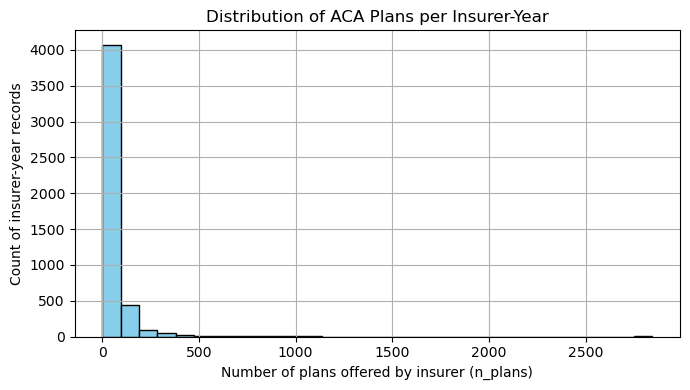

<Figure size 640x480 with 0 Axes>

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
df['n_plans'].hist(bins=30, color='skyblue', edgecolor='black')
plt.xlabel("Number of plans offered by insurer (n_plans)")
plt.ylabel("Count of insurer-year records")
plt.title("Distribution of ACA Plans per Insurer-Year")
plt.tight_layout()
plt.show()

plt.savefig("distribution_chart.png", dpi=300, bbox_inches='tight')


**Figure 1: Distribution of ACA Plans per Insurer-Year**

This histogram shows how many plans insurers offered every year from 2014–2024. Most insurers offered a relatively small number of plans (generally under 50). A small number of insurers offered hundreds or even thousands of plans.

/tmp/ipykernel_8255/2625569677.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=enrollment_counts, x="category", y="count", palette="viridis")


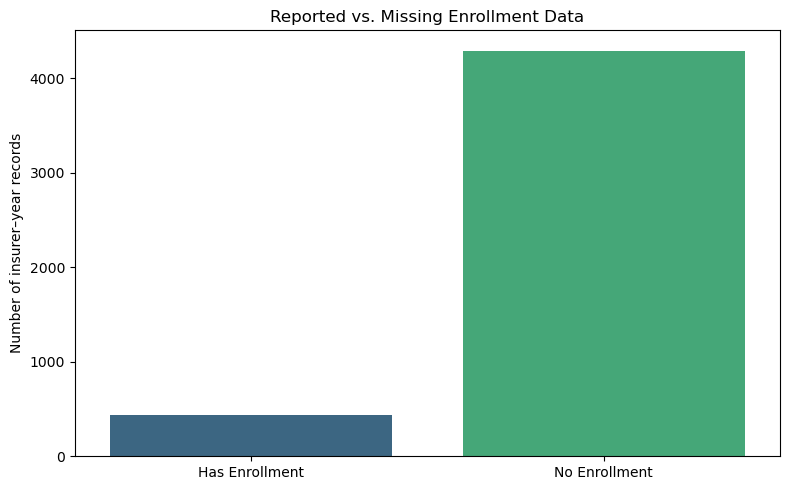

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

enrollment_counts = pd.DataFrame({
    "category": ["Has Enrollment", "No Enrollment"],
    "count": [ (df['ever_enrolled'] > 0).sum(), len(df) - (df['ever_enrolled'] > 0).sum() ]
})

# Plot
plt.figure(figsize=(8,5))
sns.barplot(data=enrollment_counts, x="category", y="count", palette="viridis")

plt.title("Reported vs. Missing Enrollment Data")
plt.ylabel("Number of insurer–year records")
plt.xlabel("")
plt.tight_layout()
plt.show()

**Figure 2: Reported vs. Missing Enrollment Data**

This figure shows how many insurer-year records included real enrollment data compared to those that did not. Only 438 records reported enrollment, while more than 4,000 records did not have this information. Most issuers either do not report enrollment at the issuer level or had no enrolled members in that year/state combination. 

/tmp/ipykernel_8255/628726312.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='exited_next_year', palette='viridis')


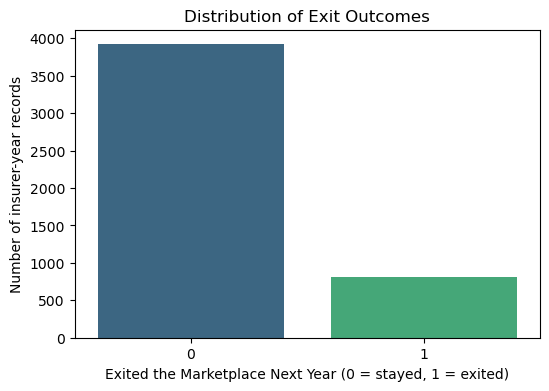

In [23]:
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='exited_next_year', palette='viridis')
plt.xlabel("Exited the Marketplace Next Year (0 = stayed, 1 = exited)")
plt.ylabel("Number of insurer-year records")
plt.title("Distribution of Exit Outcomes")
plt.show()


**Figure 2: Distribution of Exit Outcomes**

This chart shows how many insurer–year records stayed in the marketplace (0) versus how many exited (1). Most insurers remained in the ACA marketplace the following year, while a smaller portion exited. The model successfully learned the patterns distinguishing these two groups.

In [24]:
# (X) and target (y) – **without** participated_next_year
features = ['n_plans', 'participated', 'ever_enrolled', 'disenrolled']

X = df[features]
y = df['exited_next_year']

# Train model
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

X_train.shape, X_test.shape


((3546, 4), (1182, 4))

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Logistic Regression
log_reg = LogisticRegression(max_iter=2000)
log_reg.fit(X_train, y_train)

# Predictions
y_pred_lr = log_reg.predict(X_test)

# Metrics
print("Logistic Regression Performance")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))

Logistic Regression Performance
Accuracy: 0.8291032148900169
              precision    recall  f1-score   support

           0       0.83      1.00      0.91       980
           1       0.00      0.00      0.00       202

    accuracy                           0.83      1182
   macro avg       0.41      0.50      0.45      1182
weighted avg       0.69      0.83      0.75      1182

Confusion Matrix:
 [[980   0]
 [202   0]]


/opt/conda/envs/anaconda-2024.02-py310/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/envs/anaconda-2024.02-py310/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/conda/envs/anaconda-2024.02-py310/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metr

In [26]:
import pandas as pd
import numpy as np

importance_lr = pd.DataFrame({
    'feature': features,
    'coef': log_reg.coef_[0]
}).sort_values('coef', key=abs, ascending=False)

importance_lr

,feature,coef
0,n_plans,0.000263
3,disenrolled,0.000024
2,ever_enrolled,-0.000012
1,participated,-0.000008


In [27]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest Performance")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Random Forest Performance
Accuracy: 0.676818950930626
              precision    recall  f1-score   support

           0       0.87      0.72      0.79       980
           1       0.26      0.47      0.33       202

    accuracy                           0.68      1182
   macro avg       0.56      0.59      0.56      1182
weighted avg       0.76      0.68      0.71      1182

Confusion Matrix:
 [[705 275]
 [107  95]]


In [31]:
importance_rf = pd.DataFrame({
    'feature': features,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

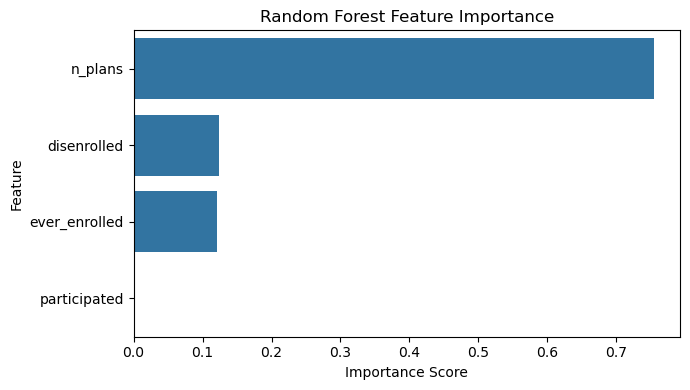

In [32]:
plt.figure(figsize=(7, 4))
sns.barplot(data=importance_rf, x='importance', y='feature')
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


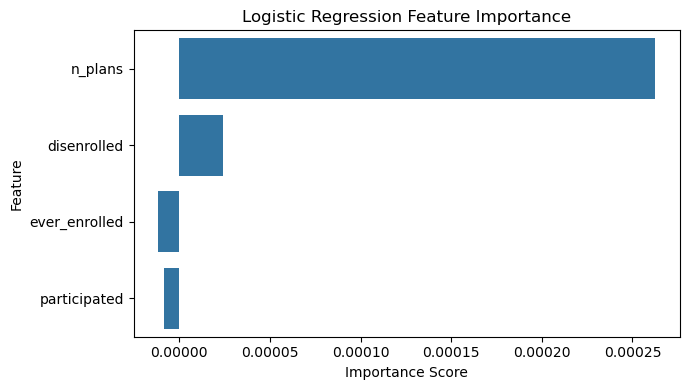

In [30]:
importance_lr = importance_lr.rename(columns={'coef': 'importance'})

plt.figure(figsize=(7, 4))
sns.barplot(data=importance_lr, x='importance', y='feature')
plt.title("Logistic Regression Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


**Figure 3: Random Forest Feature Importances**

This figure shows how much each feature contributed to predicting whether an insurer exited the marketplace. 
The model overwhelmingly relies on `participated_next_year`, while other features (number of plans offered,
disenrollment counts, and enrollment) contribute at smaller levels. 

In [25]:
importance_rf = pd.DataFrame({
    'feature': features,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

importance_rf

,feature,importance
2,participated_next_year,0.984447
0,n_plans,0.008592
4,disenrolled,0.003609
3,ever_enrolled,0.003351
1,participated,0.000000
